## Dependencies

In [ ]:
#!pip install lime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lime import lime_tabular
from xgboost import XGBRegressor, plot_tree
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## Load/Clean Data

In [96]:
# load the data
df = pd.read_csv('Access_to_Care_Dataset.csv')

# remove rows where ESTIMATE is missing
before_count = len(df)
df = df.dropna(subset=['ESTIMATE'])
removed = before_count - len(df)
print(f"Removed {removed:,} rows with missing ESTIMATE values ({removed/before_count*100:.1f}%)")

# data type optimization
df['TIME_PERIOD'] = df['TIME_PERIOD'].astype('int16')
df['ESTIMATE'] = df['ESTIMATE'].astype('float32')
df['ESTIMATE_LCI'] = df['ESTIMATE_LCI'].astype('float32')
df['ESTIMATE_UCI'] = df['ESTIMATE_UCI'].astype('float32')

# check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows")
    df = df.drop_duplicates()
    print(f"Removed duplicates")
else:
    print("No duplicate rows found")

Removed 2,369 rows with missing ESTIMATE values (9.0%)
No duplicate rows found


## Topic Correlation 2023

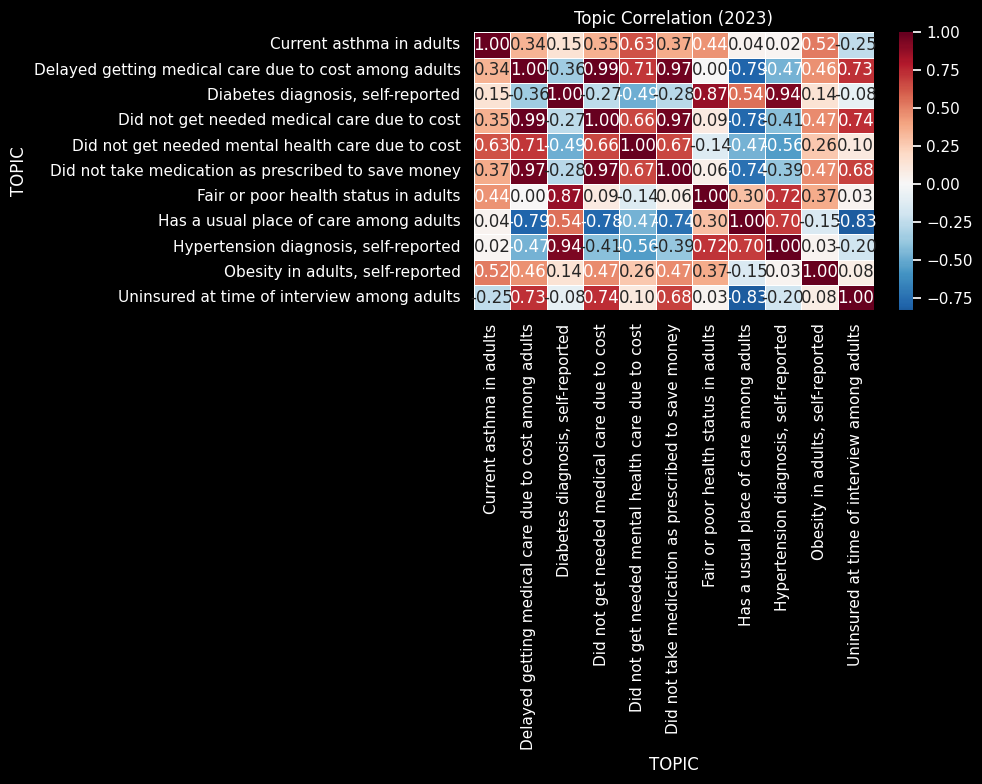

In [97]:
target_topics = [
    'Delayed getting medical care due to cost among adults',
    'Did not get needed medical care due to cost',
    'Did not get needed mental health care due to cost',
    'Did not take medication as prescribed to save money',
    'Has a usual place of care among adults',
    'Diabetes diagnosis, self-reported',
    'Hypertension diagnosis, self-reported',
    'Obesity in adults, self-reported',
    'Current asthma in adults',
    'Fair or poor health status in adults',
    'Uninsured at time of interview among adults'
]
df_2023 = df[(df['TIME_PERIOD'] == 2023) & (df['TOPIC'].isin(target_topics))].copy()
df_2023['Profile'] = df_2023['CLASSIFICATION'] + " | " + df_2023['GROUP'] + " | " + df_2023['SUBGROUP']

# handle subgroup nesting
df_2023['Profile'] = df_2023.apply(
    lambda x: x['Profile'] + " (" + str(x['NESTING_LABEL']) + ")" if pd.notnull(x['NESTING_LABEL']) else x['Profile'], axis=1
)

topic_df = df_2023.pivot_table(index='Profile', columns='TOPIC', values='ESTIMATE')
corr = topic_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)

plt.title('Topic Correlation (2023)')
plt.tight_layout()

## Topic Clustering

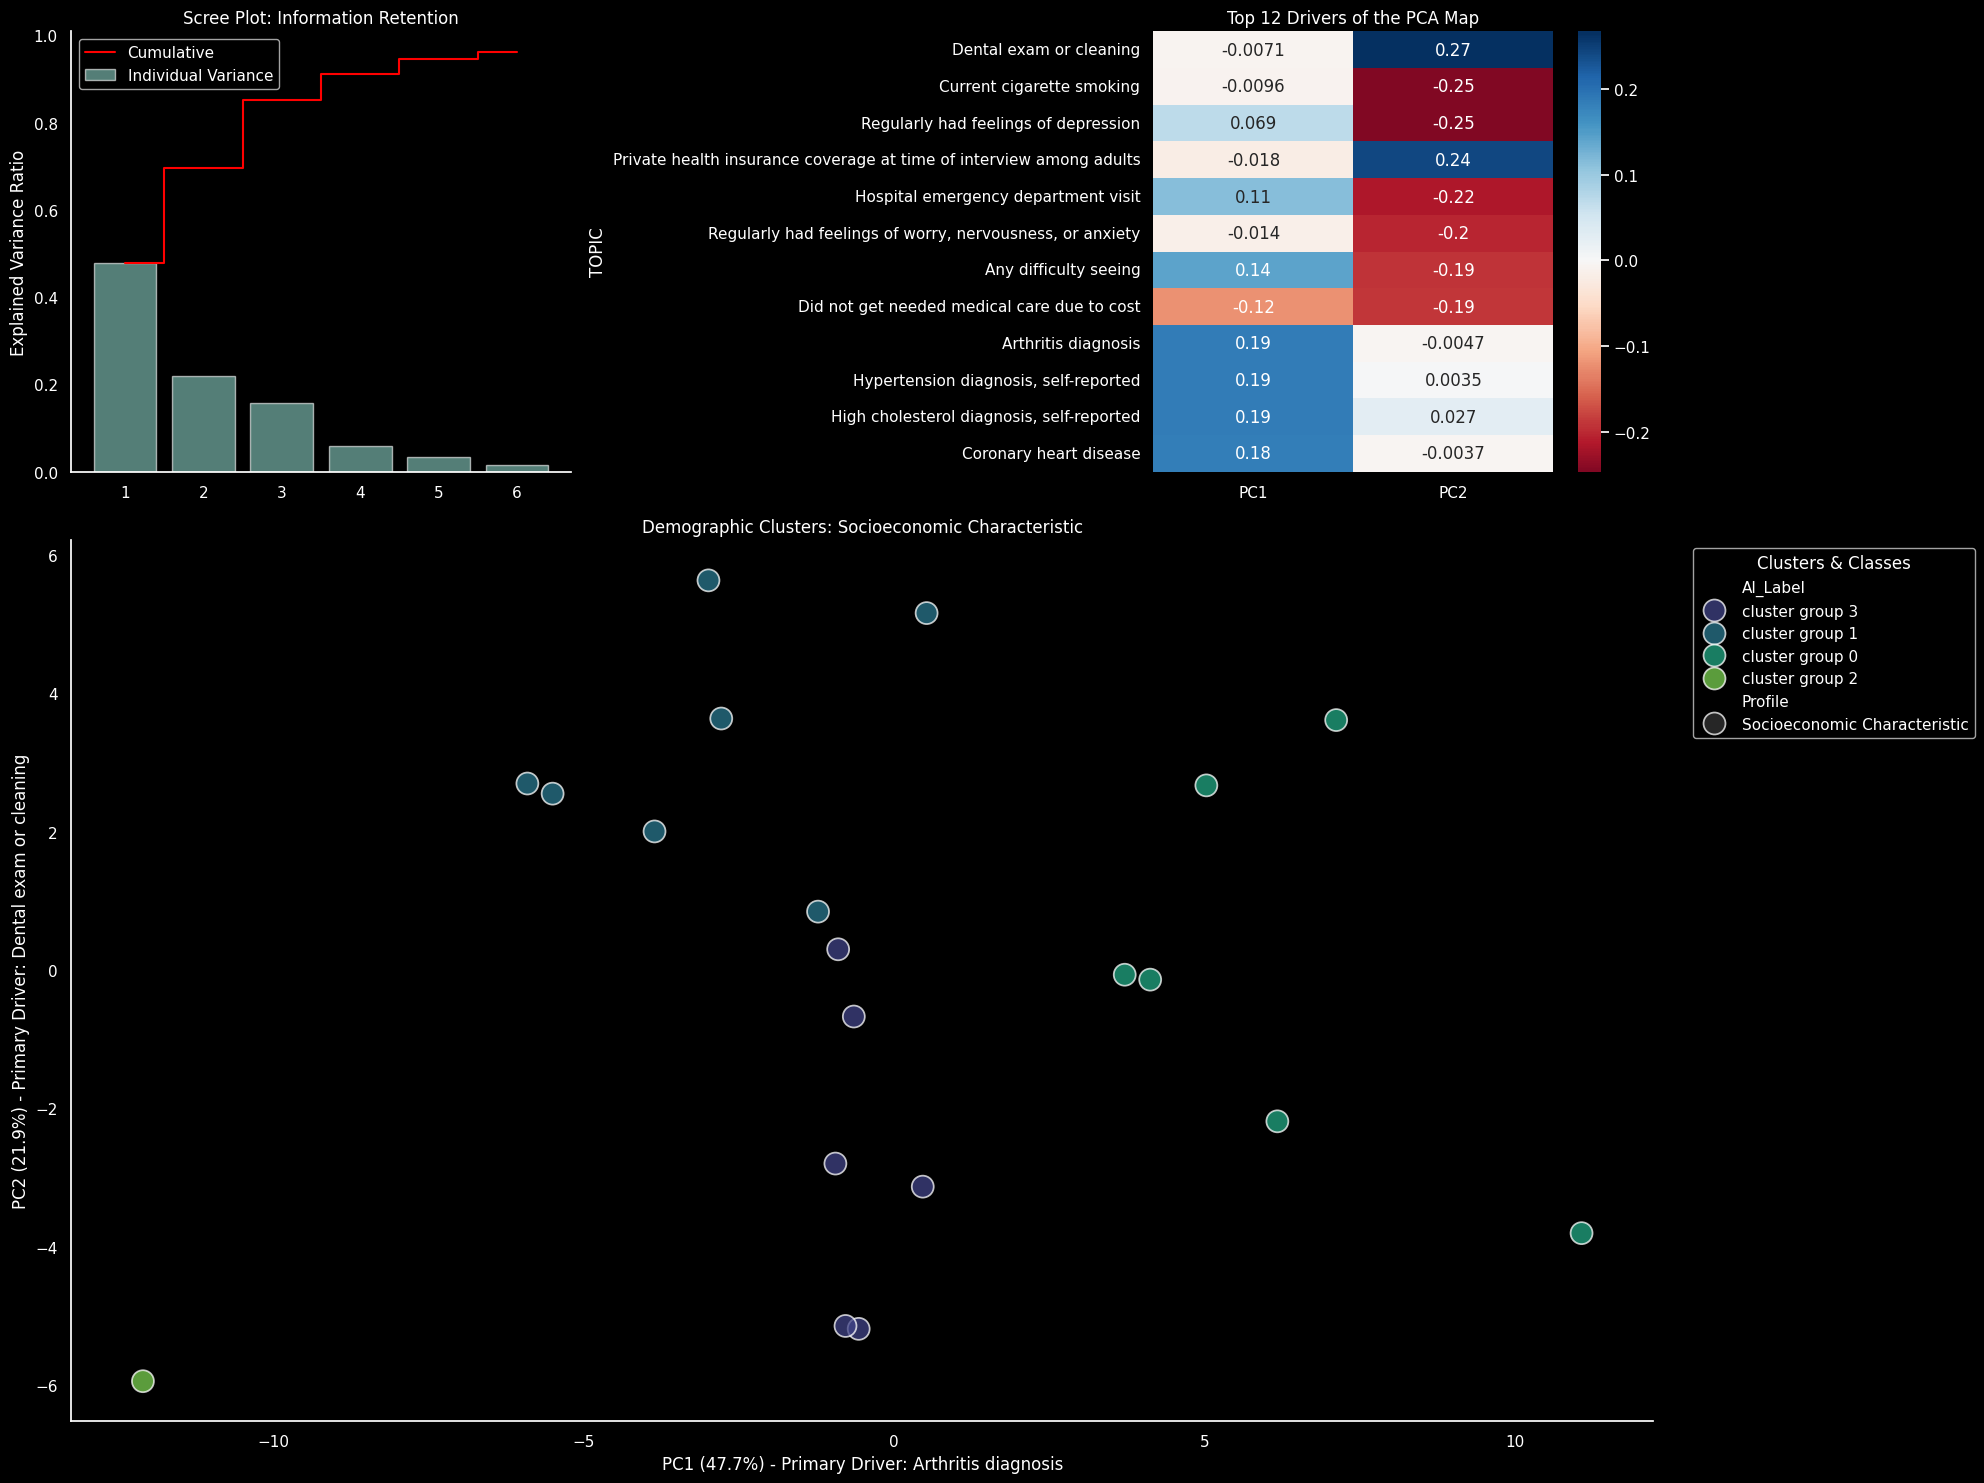


--- cluster group 0 (cluster 0) ---
 • Socioeconomic Characteristic | Medicare Advantage
 • Socioeconomic Characteristic | Medicare and Medicaid
 • Socioeconomic Characteristic | Medicare only excluding Medicare Advantage
 • Socioeconomic Characteristic | Not employed (Not employed)
 • Socioeconomic Characteristic | Not employed - Has worked previously (Not employed)
 • Socioeconomic Characteristic | Other government coverage

--- cluster group 1 (cluster 1) ---
 • Socioeconomic Characteristic | College degree or higher
 • Socioeconomic Characteristic | Employed (Employed)
 • Socioeconomic Characteristic | Employed - Full-time (Employed)
 • Socioeconomic Characteristic | Employed - Part-time (Employed)
 • Socioeconomic Characteristic | Not employed - Has never worked (Not employed)
 • Socioeconomic Characteristic | Private
 • Socioeconomic Characteristic | ≥200% FPL

--- cluster group 2 (cluster 2) ---
 • Socioeconomic Characteristic | Uninsured

--- cluster group 3 (cluster 3) ---
 •

In [98]:
# @title PCA Analysis { run: "auto" }
view_filter = "Socioeconomic Characteristic" # @param ["All", "Demographic Characteristic", "Socioeconomic Characteristic", "Geographic Characteristic"]
n_clusters = 4 # @param {type:"slider", min:2, max:10, step:1}

# data prep & cleaning
df_2023 = df[(df['TIME_PERIOD'] == 2023) & (df['CLASSIFICATION'] != 'Total')].copy()
if view_filter != 'All':
    df_2023 = df_2023[df_2023['CLASSIFICATION'] == view_filter]

# nesting labels included in the profile name
df_2023['Profile'] = df_2023.apply(
    lambda x: f"{x['CLASSIFICATION']} | {x['SUBGROUP']}" +
              (f" ({x['NESTING_LABEL']})" if pd.notnull(x['NESTING_LABEL']) else ""), axis=1
)

topic_df = df_2023.pivot_table(index='Profile', columns='TOPIC', values='ESTIMATE', aggfunc='mean')
topic_df_filled = topic_df.dropna(axis=1, thresh=len(topic_df) * 0.7).fillna(topic_df.mean())

# pca & k-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(topic_df_filled)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
topic_df_filled['Cluster'] = kmeans.fit_predict(X_pca[:, :2]).astype(str)

# hard-coded cluster labels
cluster_labels = {
    "0": "cluster group 0",
    "1": "cluster group 1",
    "2": "cluster group 2",
    "3": "cluster group 3",
    "4": "cluster group 4",
    "5": "cluster group 5",
    "6": "cluster group 6",
    "7": "cluster group 7",
    "8": "cluster group 8",
    "9": "cluster group 9"
}

# map labels to the dataframe
topic_df_filled['AI_Label'] = topic_df_filled['Cluster'].map(cluster_labels)

# the complete dashboard
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2])

# plot a: scree plot
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, label='Individual Variance')
ax1.step(range(1, len(exp_var) + 1), np.cumsum(exp_var), where='mid', color='red', label='Cumulative')
ax1.set_title('Scree Plot: Information Retention')
ax1.set_ylabel('Explained Variance Ratio')
ax1.legend()

# plot b: loadings heatmap
ax2 = fig.add_subplot(gs[0, 1])
# drop non-numeric columns for loadings calculation
numeric_data = topic_df_filled.drop(columns=['Cluster', 'AI_Label'])
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(exp_var))], index=numeric_data.columns)
top_features = loadings[['PC1', 'PC2']].abs().max(axis=1).sort_values(ascending=False).head(12).index
sns.heatmap(loadings.loc[top_features, ['PC1', 'PC2']], annot=True, cmap='RdBu', center=0, ax=ax2)
ax2.set_title('Top 12 Drivers of the PCA Map')

# plot c: the cluster map
ax3 = fig.add_subplot(gs[1, :])
mapping = df_2023.drop_duplicates('Profile').set_index('Profile')['CLASSIFICATION']
class_styles = topic_df_filled.index.map(mapping)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=topic_df_filled['AI_Label'],
                style=class_styles, s=250, palette='viridis', alpha=0.75, ax=ax3)

ax3.set_title(f'Demographic Clusters: {view_filter}')
ax3.set_xlabel(f'PC1 ({exp_var[0]:.1%}) - Primary Driver: {loadings["PC1"].idxmax()}')
ax3.set_ylabel(f'PC2 ({exp_var[1]:.1%}) - Primary Driver: {loadings["PC2"].idxmax()}')
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Clusters & Classes")

plt.tight_layout()
plt.show()

# neighborhood report
for c in sorted(topic_df_filled['Cluster'].unique(), key=int):
    label = cluster_labels.get(c, f"cluster {c}")
    print(f"\n--- {label} (cluster {c}) ---")
    subgroups = topic_df_filled[topic_df_filled['Cluster'] == c].index.tolist()
    for name in subgroups[:10]:
        print(f" • {name}")
    if len(subgroups) > 10:
        print(f" ... and {len(subgroups) - 10} more.")

## Delayed Care Regression

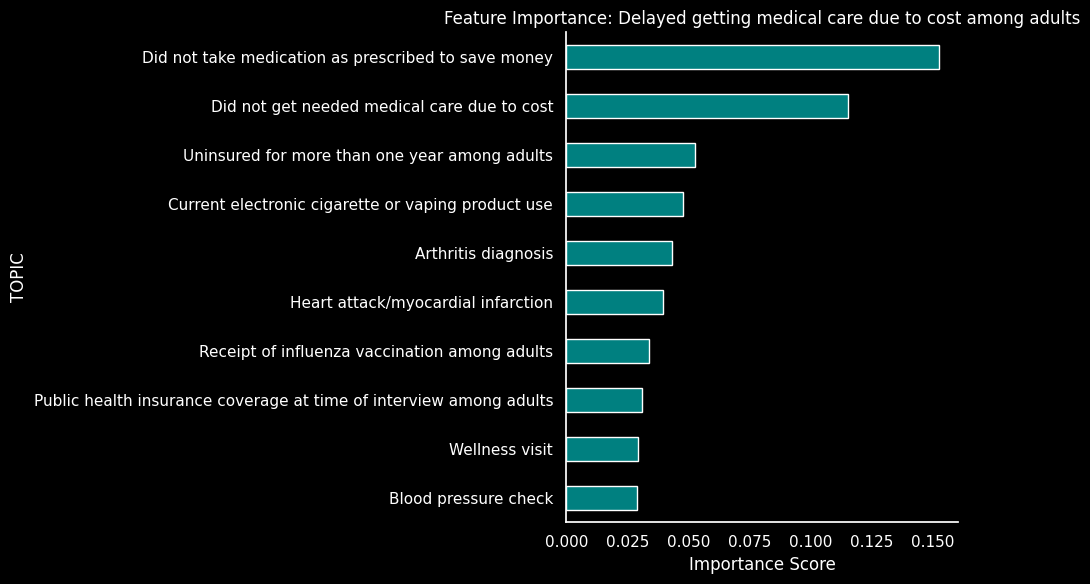

Model R² Score: 0.09


In [99]:
# define target and features
target_col = 'Delayed getting medical care due to cost among adults'

# filter x to only include numeric columns and drop the target
X = topic_df_filled.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')
y = topic_df_filled[target_col]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# extract feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# plot top 10 features
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='teal')
plt.title(f'Feature Importance: {target_col}')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

print(f"Model R² Score: {r2_score(y_test, rf.predict(X_test)):.2f}")

## Forecast Modeling

--- results for lens: Demographic Characteristic ---
xgboost r2 score: 0.9967


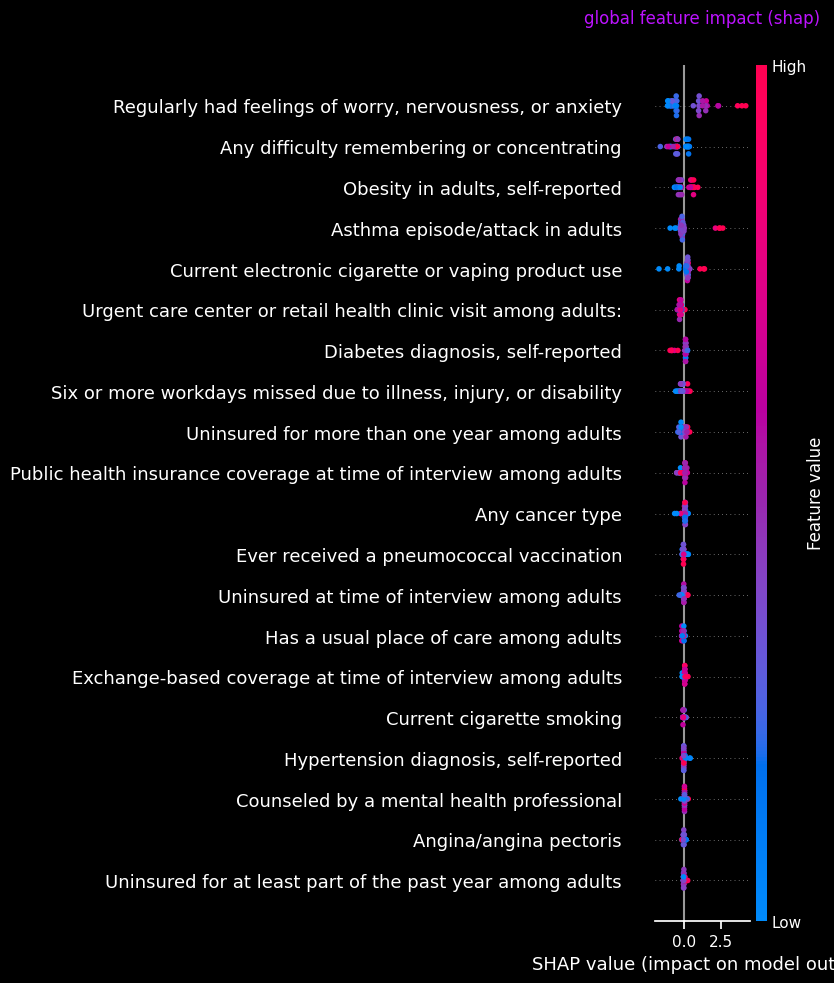

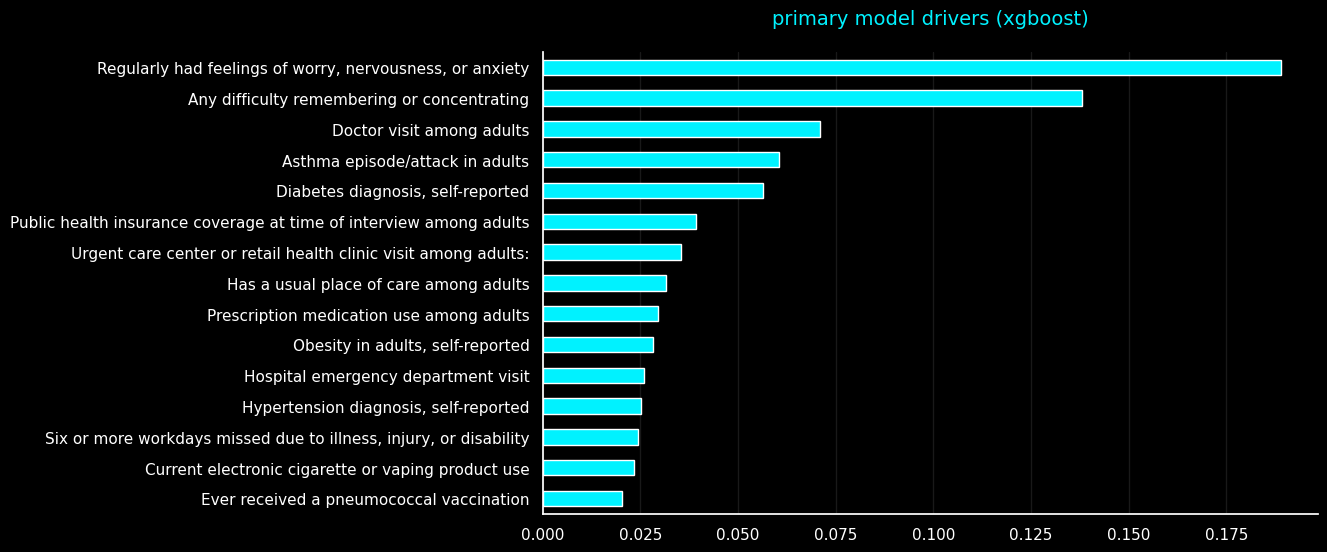

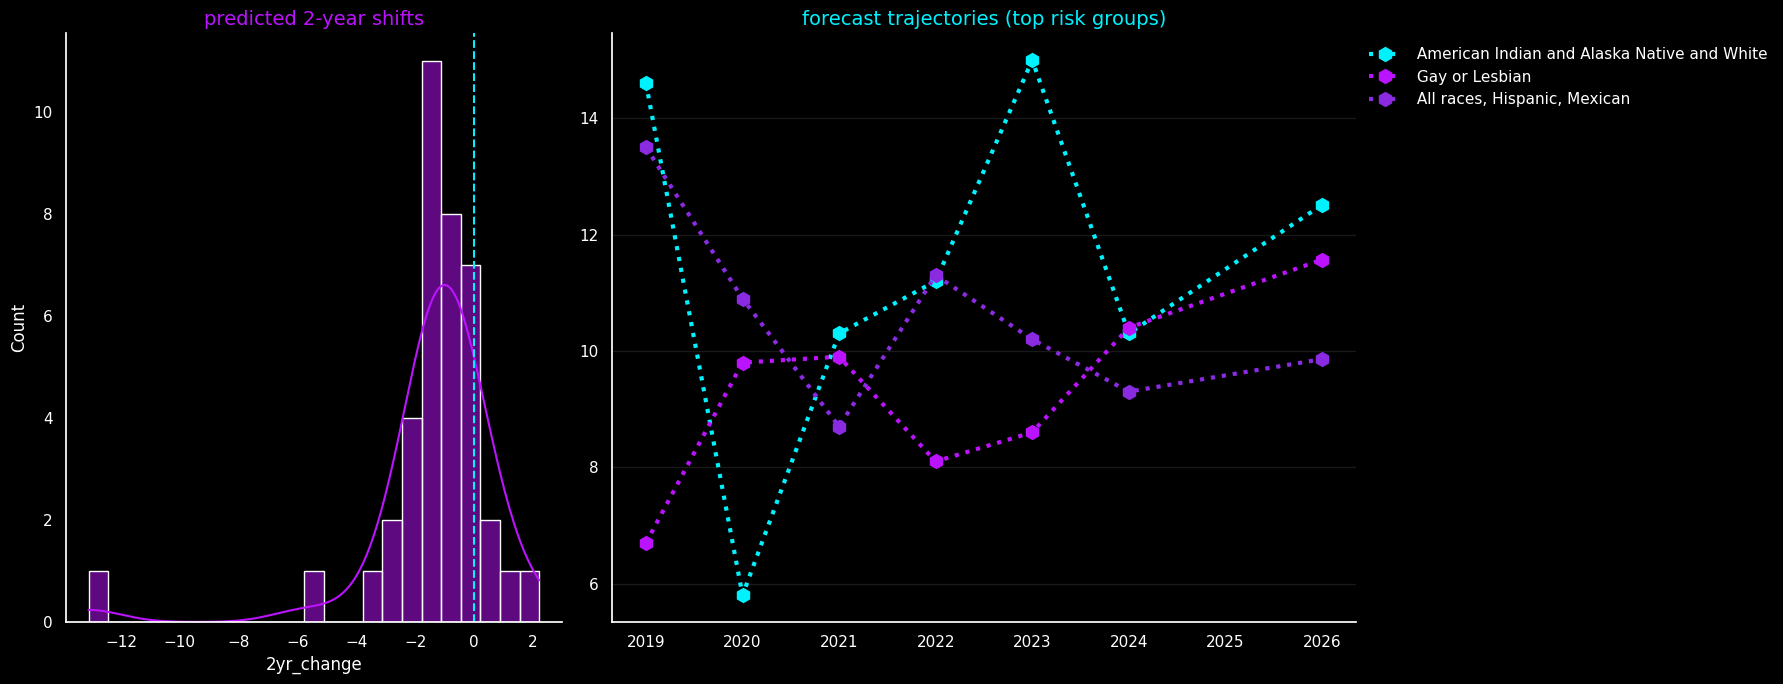


--- 2026 forecast summary (top 10 risk increases) ---
                                                    2024_actual  2026_pred  \
profile                                                                      
Demographic Characteristic | American Indian an...         10.3  12.509239   
Demographic Characteristic | Gay or Lesbian                10.4  11.568245   
Demographic Characteristic | All races, Hispani...          9.3   9.858878   
Demographic Characteristic | 65 years and older             2.6   3.113188   
Demographic Characteristic | Asian only                     3.8   3.953966   
Demographic Characteristic | 75 years and older             1.6   1.746401   
Demographic Characteristic | 65-74 years                    3.4   3.416876   
Demographic Characteristic | Widowed                        4.6   4.536917   
Demographic Characteristic | With disability               14.2  13.893715   
Demographic Characteristic | Other races, non-H...          6.1   5.681586   

        

In [ ]:
# @title 2026 delayed healthcare access forecast
# select which classification lens you want to view.
view_filter = "Socioeconomic Characteristic" # @param ["Demographic Characteristic", "Socioeconomic Characteristic", "Geographic Characteristic"]

# visual theme constants
dark_bg = '#000000'
neon_cyan = '#00f2ff'
neon_purple = '#bc13fe'
text_color = '#ffffff'

# exact string definitions
target_topic = 'Delayed getting medical care due to cost among adults'

# updated feature selection with hard-coded leakage exclusions
def prepare_features(pivot_df, target_to_drop=None):
    temp_df = pivot_df.copy().select_dtypes(include=[np.number])
    
    # specific topics to exclude to prevent data leakage
    excluded_features = [
        'Delayed getting medical care due to cost among adults',
        'Did not get needed medical care due to cost',
        'Did not get needed mental health care due to cost',
        'Did not take medication as prescribed to save money'
    ]
    
    # drop the forbidden features
    temp_df = temp_df.drop(columns=excluded_features, errors='ignore')
    
    # ensure the target is gone even if it wasn't in the list
    if target_to_drop and target_to_drop in temp_df.columns:
        temp_df = temp_df.drop(columns=[target_to_drop])
        
    # keep only features with actual movement
    return temp_df.loc[:, temp_df.std() > 0]

# pivot data and apply classification filter
years = sorted([int(y) for y in df['TIME_PERIOD'].unique()])
pivot_map = {}
for yr in years:
    df_yr = df[(df['TIME_PERIOD'] == yr) & (df['CLASSIFICATION'] == view_filter)].copy()
    if df_yr.empty: continue
    df_yr['profile'] = df_yr.apply(lambda x: f"{x['CLASSIFICATION']} | {x['SUBGROUP']}" +
                                  (f" ({x['NESTING_LABEL']})" if pd.notnull(x['NESTING_LABEL']) else ""), axis=1)
    pivot_map[yr] = df_yr.pivot_table(index='profile', columns='TOPIC', values='ESTIMATE').fillna(0)

# create 2-year jump training pairs
all_x, all_y = [], []
for i in range(len(years) - 2):
    curr_yr, jump_yr = years[i], years[i+2]
    if jump_yr in pivot_map and target_topic in pivot_map[jump_yr].columns:
        x_yr = prepare_features(pivot_map[curr_yr], target_to_drop=target_topic)
        y_yr = pivot_map[jump_yr][target_topic]
        common = x_yr.index.intersection(y_yr.index)
        if not common.empty:
            all_x.append(x_yr.loc[common]), all_y.append(y_yr.loc[common])

# validation split using the most recent historical jump
x_train_val = pd.concat(all_x[:-1]).fillna(0)
y_train_val = pd.concat(all_y[:-1])
x_test_val = all_x[-1].fillna(0)
y_test_val = all_y[-1]

# align features for validation
common_features = x_train_val.columns.intersection(x_test_val.columns)
x_train_val = x_train_val[common_features]
x_test_val = x_test_val[common_features]

# train validation model
val_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
val_model.fit(x_train_val, y_train_val)
val_preds = val_model.predict(x_test_val)
r2_val = r2_score(y_test_val, val_preds)

# train final model on full history for forecast
x_final = pd.concat(all_x).fillna(0)[common_features]
y_final = pd.concat(all_y)
final_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
final_model.fit(x_final, y_final)

# direct forecast to 2026
model_features = final_model.feature_names_in_
current_state_24 = prepare_features(pivot_map[2024], target_to_drop=target_topic).reindex(columns=model_features, fill_value=0)

# Truncate column names for SHAP labels and avoid attribute error using .values
current_state_24_trunc = current_state_24.copy()
truncated_cols = [c[:47] + '...' if len(c) > 50 else c for c in current_state_24_trunc.columns]
current_state_24_trunc.columns = truncated_cols

pred_26 = final_model.predict(current_state_24)

# compile final summary
forecast_summary = pd.DataFrame({
    '2024_actual': pivot_map[2024][target_topic],
    '2026_pred': pred_26
}, index=pivot_map[2024].index)
forecast_summary['2yr_change'] = forecast_summary['2026_pred'] - forecast_summary['2024_actual']

# style and visuals
plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': dark_bg, 'axes.facecolor': dark_bg, 'text.color': text_color})

print(f"--- results for lens: {view_filter} ---")
print(f"training samples: {len(x_train_val)} | validation samples: {len(x_test_val)}")
print(f"xgboost validation r2 score: {r2_val:.4f}")

# shap summary with attribute error fix and aggressive white text override
explainer = shap.TreeExplainer(final_model)
# FIX: pass as numpy values to avoid the 'DataFrame' object has no attribute 'dtype' error
shap_values = explainer.shap_values(current_state_24_trunc.values)

fig_shap = plt.figure(figsize=(12, 8), facecolor=dark_bg)
# Pass truncated feature names back into summary_plot
shap.summary_plot(shap_values, current_state_24_trunc, show=False)

# Re-grab axis after SHAP renders
ax = plt.gca()
ax.set_facecolor(dark_bg)
ax.tick_params(axis='both', colors='#ffffff', labelsize=10)
plt.setp(ax.get_yticklabels(), color='#ffffff', fontweight='bold')
ax.xaxis.label.set_color('#ffffff')

# Adjust colorbar if present
if len(plt.gcf().axes) > 1:
    cb_ax = plt.gcf().axes[1]
    cb_ax.tick_params(colors='#ffffff')
    cb_ax.set_ylabel('Feature Value', color='#ffffff', fontweight='bold')

plt.title("global feature impact (shap)", color=neon_purple, pad=30)
plt.show()

# feature importance
fig_imp, ax_imp = plt.subplots(figsize=(10, 6), facecolor=dark_bg)
importances = pd.Series(final_model.feature_importances_, index=model_features).sort_values(ascending=True).tail(15)
importances.plot(kind='barh', color=neon_cyan, ax=ax_imp)
ax_imp.set_title("primary model drivers (xgboost)", color=neon_cyan, fontsize=14, pad=20)
plt.show()

# trajectory visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.5]}, facecolor=dark_bg)
sns.histplot(forecast_summary['2yr_change'].dropna(), kde=True, color=neon_purple, ax=ax1, alpha=0.5)
ax1.set_title('predicted 2-year shifts', color=neon_purple)

top_groups = forecast_summary.sort_values('2yr_change', ascending=False).head(3)
plot_data = []
for p in top_groups.index:
    for yr in years:
        if p in pivot_map[yr].index:
            plot_data.append({'p': p, 'yr': yr, 'r': pivot_map[yr].loc[p, target_topic]})
    plot_data.append({'p': p, 'yr': 2026, 'r': forecast_summary.loc[p, '2026_pred']})

traj_df = pd.DataFrame(plot_data)
colors = [neon_cyan, '#bc13fe', '#8a2be2']
for i, p in enumerate(top_groups.index):
    subset = traj_df[traj_df['p'] == p]
    ax2.plot(subset['yr'], subset['r'], color=colors[i], marker='h', markersize=10, linestyle=':', linewidth=3, label=p.split('|')[-1])

ax2.set_title('forecast trajectories (top risk groups)', color=neon_cyan)
ax2.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print("\n--- 2026 forecast summary (top 10 risk increases) ---")
print(forecast_summary.sort_values('2yr_change', ascending=False).head(10))